In [1]:
import tensorflow as tf
from tensorflow import keras

# 加载 MNIST 数据集（60,000 训练，10,000 测试）
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("训练集图片数量：", x_train.shape[0])
print("测试集图片数量：", x_test.shape[0])
print("图片尺寸：", x_train.shape[1:])

训练集图片数量： 60000
测试集图片数量： 10000
图片尺寸： (28, 28)


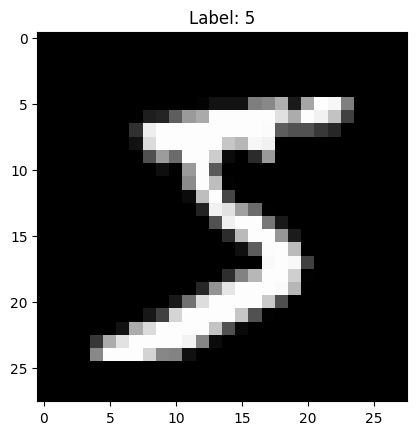

In [2]:
import matplotlib.pyplot as plt

# 随机展示一张图片
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [3]:
# 把像素归一化到0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# 编译模型
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [5]:
# 训练模型（epoch次数可调整，初学6~10即可）
history = model.fit(x_train, y_train, epochs=6, validation_data=(x_test, y_test))

Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9255 - loss: 0.2621 - val_accuracy: 0.9587 - val_loss: 0.1391
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9661 - loss: 0.1157 - val_accuracy: 0.9678 - val_loss: 0.1061
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9767 - loss: 0.0791 - val_accuracy: 0.9708 - val_loss: 0.0901
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9819 - loss: 0.0596 - val_accuracy: 0.9753 - val_loss: 0.0801
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9865 - loss: 0.0440 - val_accuracy: 0.9754 - val_loss: 0.0772
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9891 - loss: 0.0363 - val_accuracy: 0.9766 - val_loss: 0.0756


In [6]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\n测试集准确率：', test_acc)

313/313 - 0s - 2ms/step - accuracy: 0.9766 - loss: 0.0756

测试集准确率： 0.9765999913215637


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


C:\Users\27968\Desktop\0407\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\27968\Desktop\0407\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\27968\Desktop\0407\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\27968\Desktop\0407\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


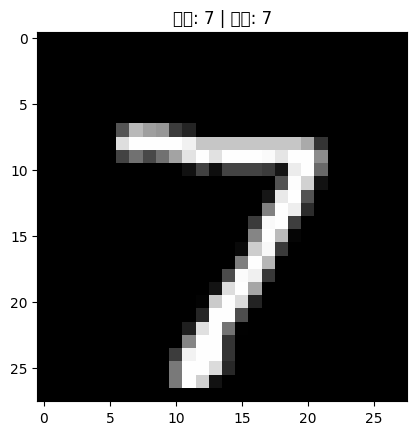

In [7]:
predictions = model.predict(x_test)  # 得到概率分布
import numpy as np

# 展示第1张图片和预测结果
plt.imshow(x_test[0], cmap='gray')
pred_num = np.argmax(predictions[0])
plt.title(f"预测: {pred_num} | 真值: {y_test[0]}")
plt.show()